# 13f — Rating-Transition Markov Generator: Climate-Stressed Default-Rate Calibration

This notebook builds a climate-stressed rating-transition generator by scaling
the default-column entries of a baseline continuous-time Markov generator by a
stress factor `beta` and re-balancing the diagonal so each row still sums to
zero — a "widen the door to default" stress. The stress is applied at two fixed
levels (`beta=2.5` and `beta=2.0`) to examine survival curves, hazard rates, and
default-time densities, then swept continuously over a range of `beta` values to
calibrate the multiplier that reproduces a target default-rate multiple (1.25x,
1.5x, and 2x the baseline).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import logm
from quanttoolbox.sustainable_finance.entropy import estimate_markov_generator
from quanttoolbox.credit.reduced_form import survival_markov_generator, density_markov_generator
from quanttoolbox.spline.spline import fit_smoothing_spline, evaluate_spline, invert_spline

color_blue      = "#1f77b4"
color_red       = "#d62728"
color_green     = "#2ca02c"
color_violet    = "#ff33ff"
color_limegreen = "#32ff32"
color_pink      = "#ffb6c1"
color_orchid    = "#da70d6"
color_black     = "#000000"

colors = [color_blue, color_red, color_green, color_violet, color_limegreen, color_pink, color_orchid]
RATINGS = ["AAA", "AA", "A", "BBB", "BB", "B", "CCC"]

plt.rcParams["figure.dpi"] = 100

P = np.array([
    [92.82, 6.50, 0.56, 0.06, 0.06, 0.00, 0.00, 0.00],
    [0.63, 91.87, 6.64, 0.65, 0.06, 0.11, 0.04, 0.00],
    [0.08, 2.26, 91.66, 5.11, 0.61, 0.23, 0.01, 0.04],
    [0.05, 0.27, 5.84, 87.74, 4.74, 0.98, 0.16, 0.22],
    [0.04, 0.11, 0.64, 7.85, 81.14, 8.27, 0.89, 1.06],
    [0.00, 0.11, 0.30, 0.42, 6.75, 83.07, 3.86, 5.49],
    [0.19, 0.00, 0.38, 0.75, 2.44, 12.03, 60.71, 23.50],
    [0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 100.00],
])
P = P / P.sum(axis=1, keepdims=True)
K = P.shape[0]

Lambda_raw = logm(P)
Lambda, _ = estimate_markov_generator(Lambda_raw)


def build_climate_stressed_generator(Lambda, beta):
    """Scale the default-column (K-th) entries of Lambda by `beta`,
    re-balancing the diagonal so row-sums stay zero."""
    stress = beta * Lambda[:, K - 1]
    Lambda_climate = Lambda.copy()
    Lambda_climate[:, K - 1] = Lambda_climate[:, K - 1] + stress
    Lambda_climate = Lambda_climate - np.diag(stress)
    return Lambda_climate


def panel_plot_2x2(t, curves, ylabel, xlim=150, ylim_max=None, ytick_idx2=None):
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    pairs = [(0, 1), (2, 3), (4, 5), (6, None)]
    for i, (ax, (c1, c2)) in enumerate(zip(axes.flat, pairs)):
        ax.plot(t, curves[:, c1], "-", color=colors[c1], linewidth=1.5, label=RATINGS[c1])
        if c2 is not None:
            ax.plot(t, curves[:, c2], "--", color=colors[c2], linewidth=1.5, label=RATINGS[c2])
        ax.grid(True, alpha=0.5)
        ax.set_xlabel("$t$", fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.legend(fontsize=10, loc="upper left" if ylabel != "$S(t)$" else "lower left")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_xlim(0, xlim)
        if ylim_max is not None:
            ax.set_ylim(0, ylim_max[i])
    plt.tight_layout()
    plt.show()


## 1. Climate-stressed generator construction and baseline survival curves

The climate-stressed generator `Lambda_Climate` (`beta=2.5`) is built and its
row sums verified to be zero. The survival curves plotted here use the
baseline (unstressed) generator `Lambda`, for reference before the
climate-adjusted curves appear in the following sections.


Lambda_Climate row sums (should all be ~0):
[-5.01118244e-16  1.62977271e-15  1.73472348e-16  5.13478149e-16
  7.07767178e-16  7.89299182e-16 -5.10008702e-16  0.00000000e+00]


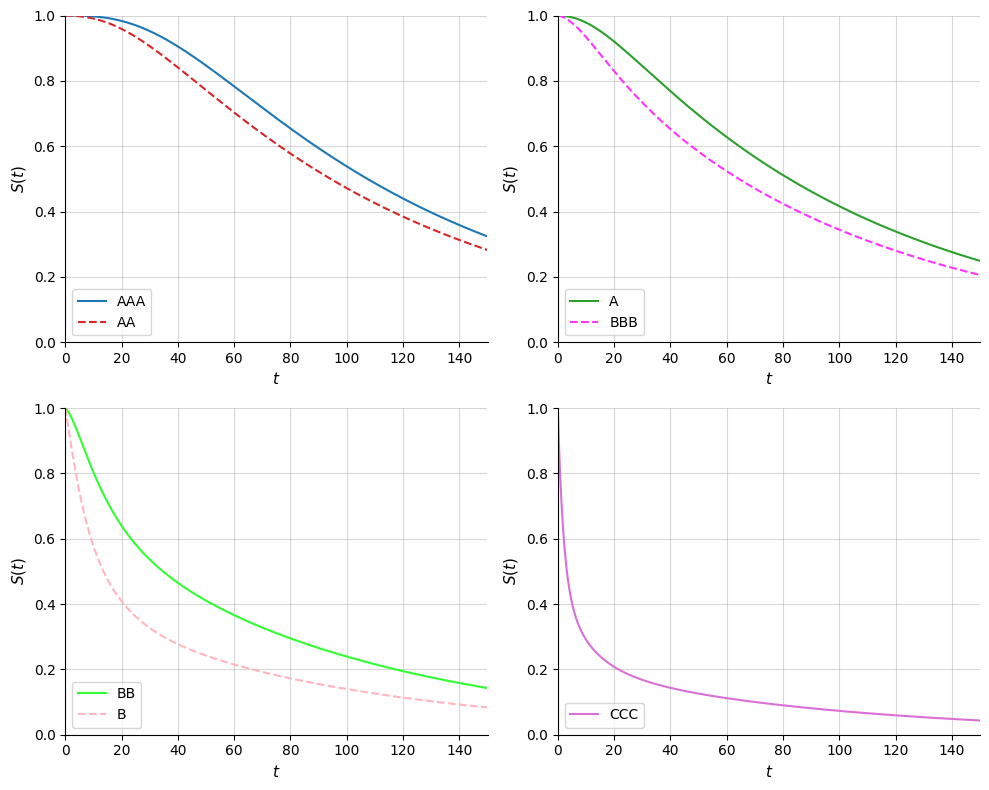

In [2]:
beta_25 = 2.5
Lambda_Climate_25 = build_climate_stressed_generator(Lambda, beta_25)
print("Lambda_Climate row sums (should all be ~0):")
print(Lambda_Climate_25.sum(axis=1))

t_fine = np.arange(0, 2001) * 0.2  # seqa(0, 1/5, 2001)
S_unstressed = survival_markov_generator(t_fine, Lambda)  # baseline (unstressed) generator

panel_plot_2x2(t_fine, S_unstressed, "$S(t)$", ylim_max=[1, 1, 1, 1])


## 2. Climate-stressed hazard rates

Using the same `Lambda_Climate` (`beta=2.5`), the hazard rate
`lambda(t) = f(t)/S(t)` is computed under the climate-stressed generator.


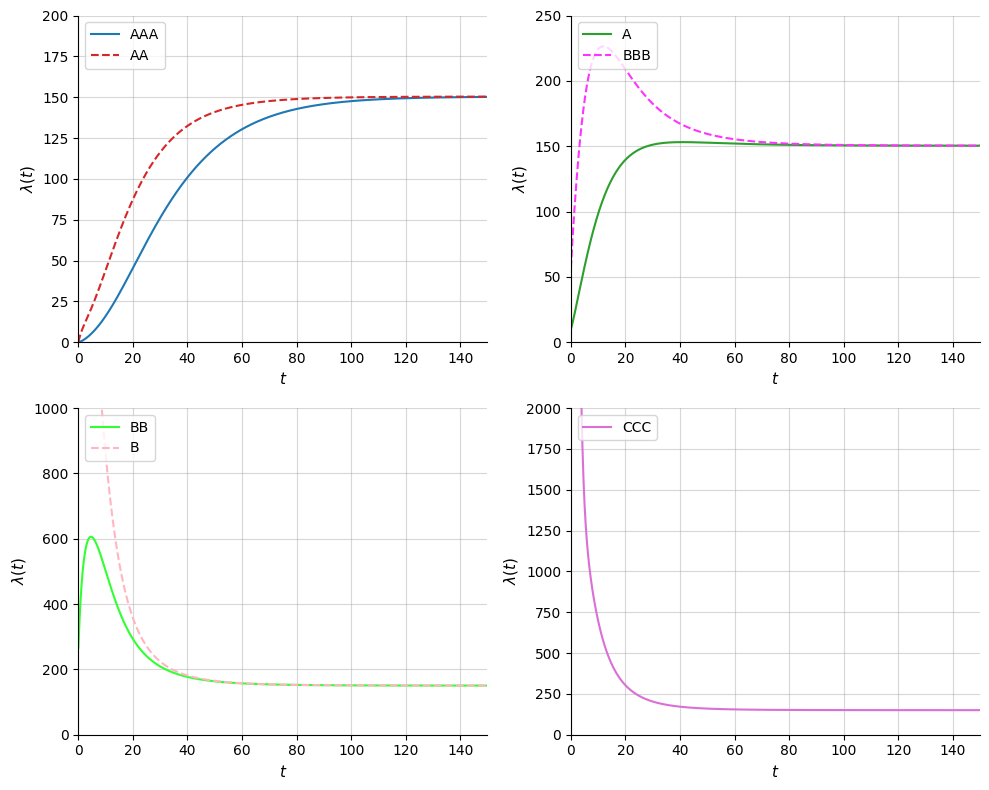

In [3]:
with np.errstate(divide="ignore", invalid="ignore"):
    S_climate_25 = survival_markov_generator(t_fine, Lambda_Climate_25)
    f_climate_25 = density_markov_generator(t_fine, Lambda_Climate_25)
    lambda_climate_25 = f_climate_25 / S_climate_25
lambda_climate_25 = 1e4 * lambda_climate_25[:, : K - 1]

panel_plot_2x2(t_fine, lambda_climate_25, r"$\lambda(t)$", ylim_max=[200, 250, 1000, 2000])


## 3. Climate-stressed default-time density

Using the same `Lambda_Climate` (`beta=2.5`), this section plots the
climate-stressed default-time density.


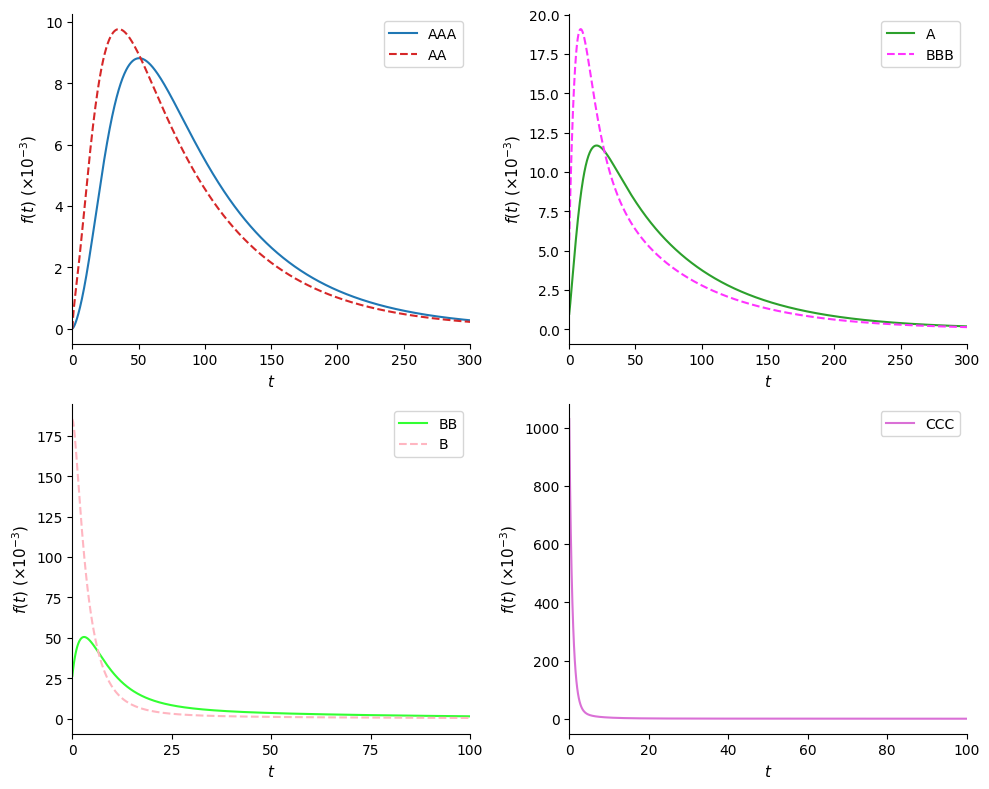

In [4]:
pdf_climate_25 = density_markov_generator(t_fine, Lambda_Climate_25)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
pairs = [(0, 1), (2, 3), (4, 5), (6, None)]
xlims = [300, 300, 100, 100]
for i, (ax, (c1, c2)) in enumerate(zip(axes.flat, pairs)):
    ax.plot(t_fine, 1e3 * pdf_climate_25[:, c1], "-", color=colors[c1], linewidth=1.5, label=RATINGS[c1])
    if c2 is not None:
        ax.plot(t_fine, 1e3 * pdf_climate_25[:, c2], "--", color=colors[c2], linewidth=1.5, label=RATINGS[c2])
    ax.set_xlabel("$t$", fontsize=11)
    ax.set_ylabel(r"$f(t)$ ($\times 10^{-3}$)", fontsize=11)
    ax.legend(fontsize=10, loc="upper right")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlim(0, xlims[i])
    if i == 2:
        ax.set_xticks(range(0, 101, 25))
plt.tight_layout()
plt.show()


## 4. Baseline vs. climate PD and hazard-rate tables at discrete horizons

Using `Lambda_Climate` at `beta=2.0`, evaluated at 7 horizons
(1, 5, 10, 20, 30, 50, 1000y): a baseline-vs-climate PD table (6 finite
horizons only) and a baseline-vs-climate hazard-rate table (all 7,
including the `t=1000` long-run asymptotic hazard).


In [5]:
beta_20 = 2.0
Lambda_Climate_20 = build_climate_stressed_generator(Lambda, beta_20)
print("Lambda_Climate row sums (should all be ~0):", Lambda_Climate_20.sum(axis=1).max())

t13a = np.array([1, 5, 10, 20, 30, 50, 1000], dtype=float)
with np.errstate(divide="ignore", invalid="ignore"):
    S13a = survival_markov_generator(t13a, Lambda)
    f13a = density_markov_generator(t13a, Lambda)
    lambda13a = f13a / S13a
    S13a_c = survival_markov_generator(t13a, Lambda_Climate_20)
    f13a_c = density_markov_generator(t13a, Lambda_Climate_20)
    lambda13a_c = f13a_c / S13a_c
PD13a, PD13a_c = 1 - S13a, 1 - S13a_c

pd_table = pd.DataFrame(
    np.vstack([100 * PD13a[:-1, : K - 1], 100 * PD13a_c[:-1, : K - 1]]),
    index=pd.MultiIndex.from_product([["Baseline", "Climate"], t13a[:-1].astype(int)], names=["Scenario", "t"]),
    columns=RATINGS,
)
print("PD (%) at each horizon:")
display(pd_table.round(2))

hazard_table = pd.DataFrame(
    np.vstack([1e4 * lambda13a[:, : K - 1], 1e4 * lambda13a_c[:, : K - 1]]),
    index=pd.MultiIndex.from_product([["Baseline", "Climate"], t13a.astype(int)], names=["Scenario", "t"]),
    columns=RATINGS,
)
print("Hazard rate (bps) at each horizon (including t=1000, the long-run asymptotic rate):")
display(hazard_table.round(1))


Lambda_Climate row sums (should all be ~0): 1.6297727056802103e-15
PD (%) at each horizon:


AAA     AA      A    BBB     BB      B    CCC
Scenario t                                                  
Baseline 1    0.00   0.01   0.04   0.22   1.06   5.49  23.50
         5    0.04   0.24   0.55   2.22   8.74  25.67  59.51
         10   0.26   0.94   2.15   6.56  19.68  42.28  70.85
         20   1.67   4.11   7.96  17.02  36.07  59.13  79.21
         30   4.77   9.38  15.45  26.63  46.38  67.32  83.20
         50  15.31  22.84  30.47  41.67  58.96  75.78  87.41
Climate  1    0.00   0.03   0.12   0.65   3.07  15.38  54.64
         5    0.10   0.54   1.45   5.59  20.65  54.51  88.17
         10   0.58   2.01   4.92  14.20  38.72  73.04  92.59
         20   3.30   7.87  15.16  30.26  57.58  84.28  95.29
         30   8.66  16.37  26.15  42.12  66.57  88.08  96.31
         50  24.37  34.82  44.84  58.14  76.42  91.72  97.38

Hazard rate (bps) at each horizon (including t=1000, the long-run asymptotic rate):


AAA     AA      A    BBB     BB       B     CCC
Scenario t                                                      
Baseline 1       0.2    2.1    5.4   27.9  134.3   591.0  2419.1
         5       2.2    9.1   21.2   71.6  244.1   571.6   976.1
         10      7.0   19.8   43.3  105.9  254.8   441.2   466.4
         20     22.5   45.2   75.8  124.3  199.4   270.0   256.7
         30     41.6   66.8   91.7  120.5  156.1   187.2   178.8
         50     73.2   90.2  101.2  110.0  118.7   125.8   122.9
         1000  102.8  102.8  102.8  102.8  102.8   102.8   102.8
Climate  1       0.5    5.4   15.9   80.0  381.6  1710.5  6877.0
         5       5.1   19.8   51.5  166.0  546.9  1319.8  1391.3
         10     14.6   40.4   89.9  207.1  469.3   811.5   679.1
         20     42.1   81.5  131.0  198.6  285.0   357.4   306.6
         30     71.5  109.8  143.6  175.3  203.9   222.6   202.3
         50    112.7  134.5  146.3  153.2  157.7   159.9   154.9
         1000  144.3  144.3  144.3  144.3  144.3   144.3   144.3

## 5. Baseline vs. climate S/PD/f/lambda for one rating

Using the same `beta=2.0`-stressed generator over a full time grid
(0-49y at 1y steps, then 50-100y at 2y steps), this section compares
`S(t)`/`PD(t)`/`f(t)`/`lambda(t)` for the BBB rating, baseline vs. climate
overlaid on each of four panels.


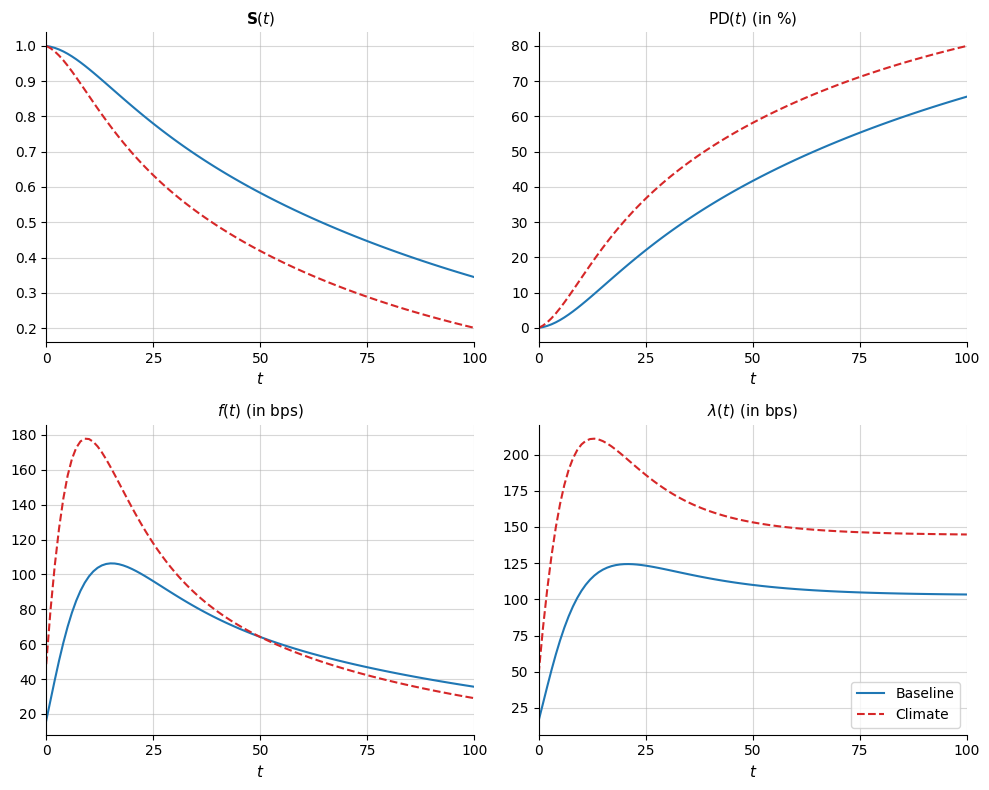

In [6]:
t13b = np.concatenate([np.arange(0, 50), np.arange(50, 101, 2)]).astype(float)
indx = 3  # BBB

with np.errstate(divide="ignore", invalid="ignore"):
    S13b = survival_markov_generator(t13b, Lambda)
    f13b = density_markov_generator(t13b, Lambda)
    lambda13b = f13b / S13b
    S13b_c = survival_markov_generator(t13b, Lambda_Climate_20)
    f13b_c = density_markov_generator(t13b, Lambda_Climate_20)
    lambda13b_c = f13b_c / S13b_c
PD13b, PD13b_c = 1 - S13b, 1 - S13b_c

y1 = np.column_stack([S13b[:, indx], 100 * PD13b[:, indx], 1e4 * f13b[:, indx], 1e4 * lambda13b[:, indx]])
y2 = np.column_stack([S13b_c[:, indx], 100 * PD13b_c[:, indx], 1e4 * f13b_c[:, indx], 1e4 * lambda13b_c[:, indx]])

titles13b = [r"$\mathbf{S}(t)$", r"$\mathrm{PD}(t)$ (in %)", "$f(t)$ (in bps)", r"$\lambda(t)$ (in bps)"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for i, ax in enumerate(axes.flat):
    ax.plot(t13b, y1[:, i], "-", color=color_blue, linewidth=1.5, label="Baseline")
    ax.plot(t13b, y2[:, i], "--", color=color_red, linewidth=1.5, label="Climate")
    ax.grid(True, alpha=0.5)
    ax.set_xlabel("$t$", fontsize=11)
    ax.set_title(titles13b[i], fontsize=11)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlim(0, 100)
    ax.set_xticks(range(0, 101, 25))
    if i == 3:
        ax.legend(fontsize=10, loc="lower right")
plt.tight_layout()
plt.show()


## 6. Calibrating the stress multiplier `beta` to a target default-rate multiple

This section sweeps the stress multiplier `beta` itself (0-10, not fixed at
`2.0`/`2.5`) and tracks the resulting long-run (`t=1000`, the asymptotic
hazard rate) AAA hazard rate. A smoothing spline is fit through
`(beta, default_rate)` and inverted to find the `beta` values that reproduce
`1.25x`/`1.5x`/`2x` the baseline (`beta=0`) default rate.

Since only the `t=1000` (long-run) value of each hazard curve is needed, it
is computed by evaluating the survival and density functions directly at
`t=1000` rather than over a full multi-thousand-point time grid — the
asymptotic value is identical either way, without the wasted computation.


Implied beta for +25%/+50%/+100% default-rate multiples: [0.97885606 2.84987314 9.97822182]


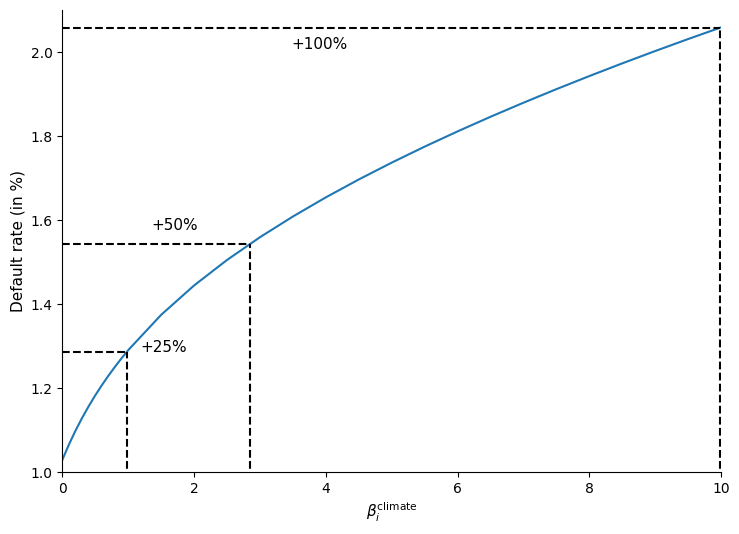

In [7]:
beta_grid = np.concatenate([np.arange(0, 0.91, 0.1), np.arange(1, 10.01, 0.5)])
t_end = np.array([1000.0])

with np.errstate(divide="ignore", invalid="ignore"):
    S_base_end = survival_markov_generator(t_end, Lambda)
    f_base_end = density_markov_generator(t_end, Lambda)
    base_rate = float((f_base_end / S_base_end)[0, 0])  # AAA

    default_rate = np.zeros((len(beta_grid), 2))
    for i, b in enumerate(beta_grid):
        Lc = build_climate_stressed_generator(Lambda, b)
        S_c = survival_markov_generator(t_end, Lc)
        f_c = density_markov_generator(t_end, Lc)
        default_rate[i, 0] = base_rate
        default_rate[i, 1] = float((f_c / S_c)[0, 0])

c_spline = fit_smoothing_spline(beta_grid, default_rate[:, 1], np.ones_like(beta_grid), 1.00)
target = default_rate[0, 1] * np.array([1.25, 1.5, 2.00])
implied_beta = invert_spline(c_spline, target)
print("Implied beta for +25%/+50%/+100% default-rate multiples:", implied_beta)

fig, ax = plt.subplots(figsize=(8.5, 6))
ax.plot(beta_grid, 100 * default_rate[:, 1], "-", color=color_blue, linewidth=1.5)

text_labels = ["+25%", "+50%", "+100%"]
delta_x = [0.2, -1.5, -6.5]
delta_y = [0.0, 0.035, -0.05]
for i in range(3):
    ax.plot([implied_beta[i], implied_beta[i]], [0, 100 * target[i]], "--", color=color_black, linewidth=1.5)
    ax.plot([0, implied_beta[i]], [100 * target[i], 100 * target[i]], "--", color=color_black, linewidth=1.5)
    ax.text(implied_beta[i] + delta_x[i], 100 * target[i] + delta_y[i], text_labels[i], fontsize=11)

ax.set_xlabel(r"$\beta_i^{\mathrm{climate}}$", fontsize=11)
ax.set_ylabel("Default rate (in %)", fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, 10)
ax.set_ylim(1, 2.1)
ax.set_yticks(np.arange(1, 2.01, 0.20))
plt.show()
